# Decoder-Only LLM Classification Baselines

Runs three OpenAI models (zero-shot and few-shot) on all three classification tasks:
- **Perpetrator** (single-label: Maoist / Security / Unknown)
- **Action Type** (multi-label: 7 categories)
- **Target Type** (multi-label: 9 categories)

Models tested:
- GPT-4o-mini (cheap, fast baseline)
- GPT-4.1-mini (newer, better instruction following)
- GPT-5.2 (frontier model)

Results are saved to `papers/classification/results/` for integration with encoder comparison figures.

## 1. Setup & Configuration

In [1]:
import os
import sys
import json
from pathlib import Path

import pandas as pd
import numpy as np
from dotenv import load_dotenv

# Paths
REPO_ROOT = Path("../../..").resolve()
DATA_DIR = REPO_ROOT / "data"
RESULTS_DIR = REPO_ROOT / "papers" / "classification" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Load .env from repo root
load_dotenv(REPO_ROOT / ".env")

# Add utils to path
sys.path.insert(0, str(REPO_ROOT / "models" / "classification-models"))

from utils.llm_classification_utils import (
    run_openai_classification_batch,
    time_inference_call,
    singlelabel_predictions_to_df,
    multilabel_predictions_to_df,
    save_run_results,
    ACTION_LABELS,
    ACTION_LABEL_MAP,
    TARGET_LABELS,
    TARGET_LABEL_MAP,
    PERPETRATOR_LABELS,
)
from utils.multilabel_utils import create_fixed_splits

# Models to evaluate
MODELS = [
    {"name": "gpt-4o-mini", "label": "GPT-4o-mini"},
    {"name": "gpt-4.1-mini", "label": "GPT-4.1-mini"},
    {"name": "gpt-5.2", "label": "GPT-5.2"},
]

# Skip models that already completed (set to empty list to run all)
SKIP_MODELS = ["gpt-4o-mini", "gpt-4.1-mini"]

assert os.environ.get("OPENAI_API_KEY"), "Set OPENAI_API_KEY in .env or shell environment"

print(f"Data dir: {DATA_DIR}")
print(f"Results dir: {RESULTS_DIR}")
print(f"Models: {[m['label'] for m in MODELS if m['name'] not in SKIP_MODELS]}")
if SKIP_MODELS:
    print(f"Skipping (already done): {SKIP_MODELS}")

/Users/ejt/Library/CloudStorage/Dropbox/projects/satp/code-satp/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data dir: /Users/ejt/Library/CloudStorage/Dropbox/projects/satp/code-satp/data
Results dir: /Users/ejt/Library/CloudStorage/Dropbox/projects/satp/code-satp/papers/classification/results
Models: ['GPT-5.2']
Skipping (already done): ['gpt-4o-mini', 'gpt-4.1-mini']


## 2. Load Data & Create Fixed Splits

In [2]:
# --- Perpetrator (single-label) ---
df_perp = pd.read_csv(DATA_DIR / "perpetrator.csv")
print(f"Perpetrator: {len(df_perp)} rows")
print(df_perp["perpetrator"].value_counts())

# For perpetrator, create splits using sklearn's stratified split
from sklearn.model_selection import train_test_split

perp_trainval, perp_test = train_test_split(
    df_perp, test_size=0.1, stratify=df_perp["perpetrator"], random_state=42
)
perp_train, perp_val = train_test_split(
    perp_trainval, test_size=0.111, stratify=perp_trainval["perpetrator"], random_state=42
)
print(f"\nPerpetrator splits: train={len(perp_train)}, val={len(perp_val)}, test={len(perp_test)}")

Perpetrator: 9914 rows
perpetrator
Maoist      5190
Security    4263
Unknown      461
Name: count, dtype: int64

Perpetrator splits: train=7931, val=991, test=992


In [3]:
# --- Action Type (multi-label) ---
df_action = pd.read_csv(DATA_DIR / "action_type.csv")
action_cols = ["armed_assault", "arrest", "bombing", "infrastructure", "surrender", "seizure", "abduction"]
print(f"Action Type: {len(df_action)} rows")
print(df_action[action_cols].sum())

action_train, action_val, action_test = create_fixed_splits(
    df_action, stratify_cols=action_cols, test_size=0.1, val_size=0.111, random_state=42
)
print(f"\nAction Type splits: train={len(action_train)}, val={len(action_val)}, test={len(action_test)}")

Action Type: 9921 rows
armed_assault     3576
arrest            3051
bombing           1141
infrastructure    1099
surrender          775
seizure           2148
abduction          473
dtype: int64

Action Type splits: train=7931, val=1005, test=985


In [4]:
# --- Target Type (multi-label) ---
df_target = pd.read_csv(DATA_DIR / "target_type.csv")
target_cols = [
    "civilians", "maoist", "government_officials", "security",
    "private_property", "mining_company", "government_infrastructure",
    "non_maoist_armed_group", "no_target",
]
print(f"Target Type: {len(df_target)} rows")
print(df_target[target_cols].sum())

target_train, target_val, target_test = create_fixed_splits(
    df_target, stratify_cols=target_cols, test_size=0.1, val_size=0.111, random_state=42
)
print(f"\nTarget Type splits: train={len(target_train)}, val={len(target_val)}, test={len(target_test)}")

Target Type: 9921 rows
civilians                    1588
maoist                       4478
government_officials          532
security                     1030
private_property              636
mining_company                 68
government_infrastructure     963
non_maoist_armed_group         60
no_target                    1318
dtype: int64

Target Type splits: train=7942, val=996, test=983


## 3. Few-Shot Examples

Hand-picked examples for each task. Edit these to improve few-shot performance.

In [5]:
# --- Perpetrator: 3 examples (one per class) ---
PERP_FEW_SHOT = [
    {
        "text": "Maoists killed Constable Krishnalal Dhurtlahare in Dantewada District.",
        "label": "Maoist",
    },
    {
        "text": "Acting on a tip off, Police arrested a CPI-Maoist cadre, identified as Bhola Ram, from Basata village under Telpa Police Station limits in Arwal District.",
        "label": "Security",
    },
    {
        "text": "Bokaro Police and the CRPF troopers were engaged in an encounter with the CPI-Maoist cadres at Kanshidih forest area in Jhumra under Gomia Police Station of Bokaro District.",
        "label": "Unknown",
    },
]

# --- Action Type: 5 examples ---
ACTION_FEW_SHOT = [
    {
        "text": "CPI-Maoist cadres shot dead a leader of the Congress party, Shaik Sabakthulla, at Madithadu village in the Cuddapah District.",
        "label": "Armed Assault",
    },
    {
        "text": "Three Maoists surrendered before the Police in Dornapal town of Sukma District.",
        "label": "Surrender",
    },
    {
        "text": "Two CRPF troopers were killed and three others were injured when Maoists triggered an explosive, when they were on way to a polling station in Jamui District parliamentary constituency.",
        "label": "Bombing",
    },
    {
        "text": "Three cadres of the PLFI, a breakaway faction of the CPI-Maoist, including an 'area commander', were arrested from Dhodhtritoli under Raidih Police Station in Gumla District. Gumla SP Jatin Narwal said the arrested PLFI cadres have been identified as 'area commander' Durjan Singh, Surendra Pal Singh and Bandhan Oraon - all residents of the same Police Station areas of the District. \"Police recovered a country-made pistol, eight sim cards, a cell phone and four live bullets besides a dairy containing names of the persons from whom PLFI activists extorted levy,\" said the SP.",
        "label": "Arrest, Seizure",
    },
    {
        "text": "Three abducted Policemen, identified as Lakhan Netam, Chandrasekhar Thakur and Ramprakahs Tiwari of Amabeda Police Station, were released by the CPI-Maoist in the Kanker District. The released Policemen said they were abducted when they had gone to Sode village under Amabeda Police Station to make telephone calls to their homes. The extremists also took their mobile handsets and two motor cycles. According to the Police, the Maoists had taken them deep into the forest, tied them to trees and threatened them to quit the Police service.",
        "label": "Abduction",
    },
]

# --- Target Type: 5 examples ---
TARGET_FEW_SHOT = [
    {
        "text": "One CRPF trooper was injured when CPI-Maoist cadres triggered a series of landmines targeting the SF personnel on a combing operation in Rudakota area",
        "label": "Security",
    },
    {
        "text": "A husband and wife duo, Durjodhan Rajkowar and his wife Lalita, members of a Maoist squad operating in the Ayodhya Hills of Purulia District surrendered before the District Police.",
        "label": "No Target",
    },
    {
        "text": "CPI-Maoist cadres blew up a newly constructed health sub-centre building in Serendag village under Herhanj Police Station in Latehar District.",
        "label": "Government Infrastructure",
    },
    {
        "text": "A civilian and 11 Policeman were killed and three sustained injuries in an ambush set by the CPI-Maoist cadres in Metlaperu village forests under Bhadrakali Police Station area of Bijapur District.",
        "label": "Civilians, Security",
    },
    {
        "text": "About 150 cadres of the CPI-Maoist raided a stone-mine in Bastar region for explosives. However, when they could not find any explosive, they set ablaze eight stone crusher machines at Partha and Darbha areas of the region.",
        "label": "Mining Company",
    },
]

## 4. Inference

Run all models on 3 tasks × 2 prompting modes.

In [6]:
# Prepare test data
perp_texts = perp_test["incident_summary"].tolist()
perp_true = perp_test["perpetrator"].tolist()
action_texts = action_test["incident_summary"].tolist()
target_texts = target_test["incident_summary"].tolist()

# Collect all results
all_runs = []

def safe_model_slug(name):
    """Convert model name to filename-safe slug: gpt-4o-mini -> gpt4omini"""
    return name.replace("-", "").replace(".", "")

# Reload metrics from previously completed models
for model_cfg in MODELS:
    model_name = model_cfg["name"]
    model_label = model_cfg["label"]
    slug = safe_model_slug(model_name)

    if model_name not in SKIP_MODELS:
        continue

    print(f"\nLoading cached results for {model_label}...")
    for task, prefix_task in [("perpetrator", "perpetrator"), ("action_type", "actiontype"), ("target_type", "targettype")]:
        for mode in ["zeroshot", "fewshot"]:
            metrics_path = RESULTS_DIR / f"{prefix_task}_{slug}_{mode}_metrics.json"
            if metrics_path.exists():
                with open(metrics_path) as f:
                    data = json.load(f)
                timing = data.pop("timing", {"total_time_seconds": 0, "time_per_item_seconds": 0})
                all_runs.append((task, model_label, mode, data, timing))
                print(f"  Loaded {prefix_task}_{slug}_{mode}")
            else:
                print(f"  WARNING: {metrics_path} not found")

# Run remaining models
for model_cfg in MODELS:
    model_name = model_cfg["name"]
    model_label = model_cfg["label"]
    slug = safe_model_slug(model_name)

    if model_name in SKIP_MODELS:
        continue

    print(f"\n{'='*60}")
    print(f"MODEL: {model_label} ({model_name})")
    print(f"{'='*60}")

    # --- Perpetrator ---
    for mode, few_shot in [("zeroshot", None), ("fewshot", PERP_FEW_SHOT)]:
        print(f"\n--- Perpetrator {mode} ---")
        raw, timing = time_inference_call(
            run_openai_classification_batch,
            texts=perp_texts, task="perpetrator",
            few_shot_examples=few_shot, model_name=model_name,
        )
        pred_df, metrics = singlelabel_predictions_to_df(perp_texts, raw, perp_true)
        prefix = f"perpetrator_{slug}_{mode}"
        save_run_results(pred_df, metrics, timing, RESULTS_DIR, prefix)
        print(f"  micro-F1: {metrics['micro_f1']:.3f}  macro-F1: {metrics['macro_f1']:.3f}")
        print(f"  Time: {timing['total_time_seconds']:.1f}s ({timing['time_per_item_seconds']:.3f}s/item)")
        all_runs.append(("perpetrator", model_label, mode, metrics, timing))

    # --- Action Type ---
    for mode, few_shot in [("zeroshot", None), ("fewshot", ACTION_FEW_SHOT)]:
        print(f"\n--- Action Type {mode} ---")
        raw, timing = time_inference_call(
            run_openai_classification_batch,
            texts=action_texts, task="action_type",
            few_shot_examples=few_shot, model_name=model_name,
        )
        pred_df, metrics = multilabel_predictions_to_df(
            action_texts, raw, action_test, ACTION_LABEL_MAP, action_cols,
        )
        prefix = f"actiontype_{slug}_{mode}"
        save_run_results(pred_df, metrics, timing, RESULTS_DIR, prefix)
        print(f"  micro-F1: {metrics['micro_f1']:.3f}  macro-F1: {metrics['macro_f1']:.3f}")
        print(f"  Time: {timing['total_time_seconds']:.1f}s ({timing['time_per_item_seconds']:.3f}s/item)")
        all_runs.append(("action_type", model_label, mode, metrics, timing))

    # --- Target Type ---
    for mode, few_shot in [("zeroshot", None), ("fewshot", TARGET_FEW_SHOT)]:
        print(f"\n--- Target Type {mode} ---")
        raw, timing = time_inference_call(
            run_openai_classification_batch,
            texts=target_texts, task="target_type",
            few_shot_examples=few_shot, model_name=model_name,
        )
        pred_df, metrics = multilabel_predictions_to_df(
            target_texts, raw, target_test, TARGET_LABEL_MAP, target_cols,
        )
        prefix = f"targettype_{slug}_{mode}"
        save_run_results(pred_df, metrics, timing, RESULTS_DIR, prefix)
        print(f"  micro-F1: {metrics['micro_f1']:.3f}  macro-F1: {metrics['macro_f1']:.3f}")
        print(f"  Time: {timing['total_time_seconds']:.1f}s ({timing['time_per_item_seconds']:.3f}s/item)")
        all_runs.append(("target_type", model_label, mode, metrics, timing))

print(f"\nAll runs complete: {len(all_runs)} total")


Loading cached results for GPT-4o-mini...
  Loaded perpetrator_gpt4omini_zeroshot
  Loaded perpetrator_gpt4omini_fewshot
  Loaded actiontype_gpt4omini_zeroshot
  Loaded actiontype_gpt4omini_fewshot
  Loaded targettype_gpt4omini_zeroshot
  Loaded targettype_gpt4omini_fewshot

Loading cached results for GPT-4.1-mini...
  Loaded perpetrator_gpt41mini_zeroshot
  Loaded perpetrator_gpt41mini_fewshot
  Loaded actiontype_gpt41mini_zeroshot
  Loaded actiontype_gpt41mini_fewshot
  Loaded targettype_gpt41mini_zeroshot
  Loaded targettype_gpt41mini_fewshot

MODEL: GPT-5.2 (gpt-5.2)

--- Perpetrator zeroshot ---


Saved: /Users/ejt/Library/CloudStorage/Dropbox/projects/satp/code-satp/papers/classification/results/perpetrator_gpt52_zeroshot.csv
Saved: /Users/ejt/Library/CloudStorage/Dropbox/projects/satp/code-satp/papers/classification/results/perpetrator_gpt52_zeroshot_metrics.json
  micro-F1: 0.889  macro-F1: 0.715
  Time: 41.8s (0.042s/item)

--- Perpetrator fewshot ---


Saved: /Users/ejt/Library/CloudStorage/Dropbox/projects/satp/code-satp/papers/classification/results/perpetrator_gpt52_fewshot.csv
Saved: /Users/ejt/Library/CloudStorage/Dropbox/projects/satp/code-satp/papers/classification/results/perpetrator_gpt52_fewshot_metrics.json
  micro-F1: 0.883  macro-F1: 0.759
  Time: 39.5s (0.040s/item)

--- Action Type zeroshot ---


Saved: /Users/ejt/Library/CloudStorage/Dropbox/projects/satp/code-satp/papers/classification/results/actiontype_gpt52_zeroshot.csv
Saved: /Users/ejt/Library/CloudStorage/Dropbox/projects/satp/code-satp/papers/classification/results/actiontype_gpt52_zeroshot_metrics.json
  micro-F1: 0.893  macro-F1: 0.870
  Time: 42.5s (0.043s/item)

--- Action Type fewshot ---


Saved: /Users/ejt/Library/CloudStorage/Dropbox/projects/satp/code-satp/papers/classification/results/actiontype_gpt52_fewshot.csv
Saved: /Users/ejt/Library/CloudStorage/Dropbox/projects/satp/code-satp/papers/classification/results/actiontype_gpt52_fewshot_metrics.json
  micro-F1: 0.910  macro-F1: 0.889
  Time: 42.0s (0.043s/item)

--- Target Type zeroshot ---


Saved: /Users/ejt/Library/CloudStorage/Dropbox/projects/satp/code-satp/papers/classification/results/targettype_gpt52_zeroshot.csv
Saved: /Users/ejt/Library/CloudStorage/Dropbox/projects/satp/code-satp/papers/classification/results/targettype_gpt52_zeroshot_metrics.json
  micro-F1: 0.628  macro-F1: 0.551
  Time: 44.5s (0.045s/item)

--- Target Type fewshot ---


Saved: /Users/ejt/Library/CloudStorage/Dropbox/projects/satp/code-satp/papers/classification/results/targettype_gpt52_fewshot.csv
Saved: /Users/ejt/Library/CloudStorage/Dropbox/projects/satp/code-satp/papers/classification/results/targettype_gpt52_fewshot_metrics.json
  micro-F1: 0.627  macro-F1: 0.560
  Time: 43.1s (0.044s/item)

All runs complete: 18 total


## 5. Comparison Summary

In [7]:
summary_rows = []
for task, model_label, mode, metrics, timing in all_runs:
    summary_rows.append({
        "task": task,
        "model": model_label,
        "mode": mode,
        "micro_f1": metrics["micro_f1"],
        "macro_f1": metrics["macro_f1"],
        "weighted_f1": metrics["weighted_f1"],
        "total_time_s": timing["total_time_seconds"],
        "time_per_item_s": timing["time_per_item_seconds"],
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(RESULTS_DIR / "comparison_summary.csv", index=False)
print("\n=== Comparison Summary ===")
print(summary_df.to_string(index=False))


=== Comparison Summary ===
       task        model     mode  micro_f1  macro_f1  weighted_f1  total_time_s  time_per_item_s
perpetrator  GPT-4o-mini zeroshot  0.818548  0.605361     0.810798     45.921373         0.046292
perpetrator  GPT-4o-mini  fewshot  0.828629  0.679786     0.836874     43.463437         0.043814
action_type  GPT-4o-mini zeroshot  0.856724  0.824878     0.866604     34.025952         0.034509
action_type  GPT-4o-mini  fewshot  0.892235  0.875942     0.896634     42.147929         0.042746
target_type  GPT-4o-mini zeroshot  0.541133  0.522587     0.588909     36.819081         0.037494
target_type  GPT-4o-mini  fewshot  0.514828  0.508262     0.540955     41.533133         0.042294
perpetrator GPT-4.1-mini zeroshot  0.880040  0.678534     0.872430     26.859754         0.027076
perpetrator GPT-4.1-mini  fewshot  0.899194  0.783248     0.904590     27.286772         0.027507
action_type GPT-4.1-mini zeroshot  0.893417  0.882173     0.895455     28.889099         0

## 6. Per-Label F1 (for heatmap rows)

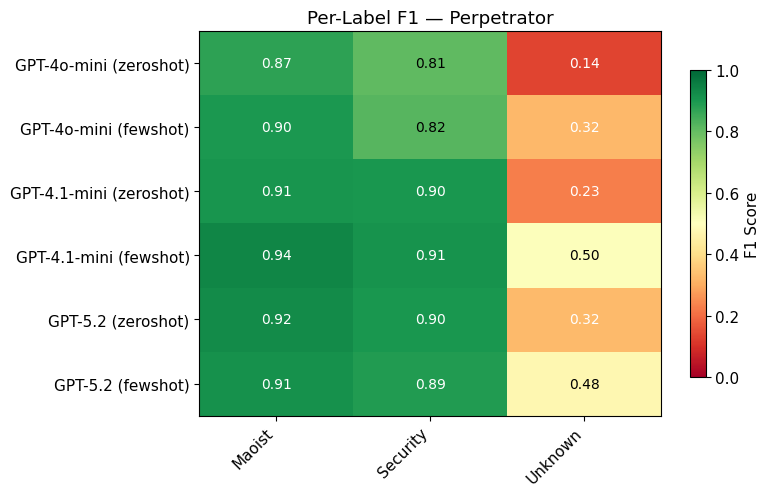

Saved: /Users/ejt/Library/CloudStorage/Dropbox/projects/satp/code-satp/papers/classification/results/perpetrator_llm_perlabel_f1_heatmap.png



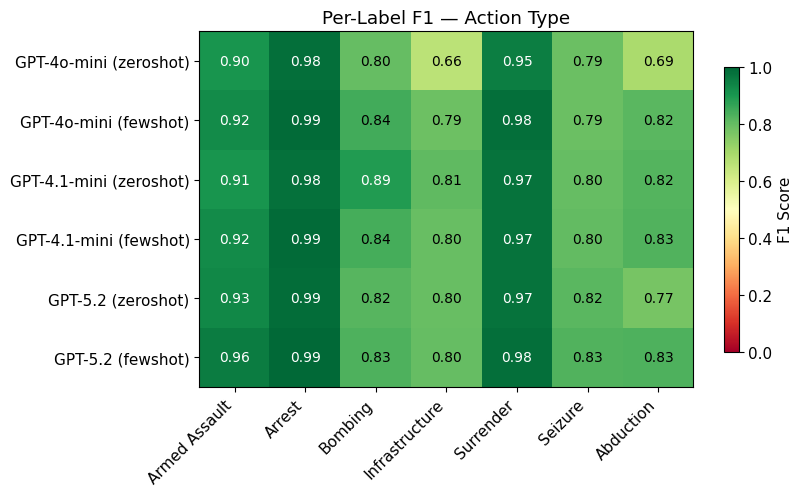

Saved: /Users/ejt/Library/CloudStorage/Dropbox/projects/satp/code-satp/papers/classification/results/action_type_llm_perlabel_f1_heatmap.png



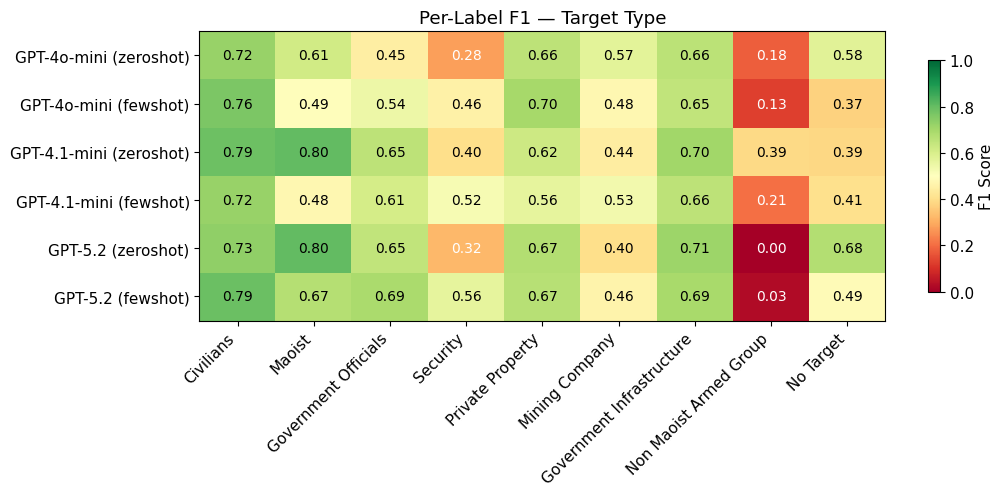

Saved: /Users/ejt/Library/CloudStorage/Dropbox/projects/satp/code-satp/papers/classification/results/target_type_llm_perlabel_f1_heatmap.png



In [8]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({"font.size": 11})

# Build per-label F1 DataFrames for each task
tasks_labels = {
    "perpetrator": PERPETRATOR_LABELS,
    "action_type": action_cols,
    "target_type": target_cols,
}

for task, labels in tasks_labels.items():
    rows = []
    for t, model_label, mode, metrics, _ in all_runs:
        if t != task:
            continue
        row = {"model": f"{model_label} ({mode})"}
        for lbl in labels:
            score = metrics["per_label"].get(lbl, {})
            row[lbl] = score.get("f1-score", 0.0) if isinstance(score, dict) else 0.0
        rows.append(row)

    df_heat = pd.DataFrame(rows).set_index("model")

    fig, ax = plt.subplots(figsize=(max(8, len(labels) * 1.2), len(rows) * 0.6 + 1.5))
    im = ax.imshow(df_heat.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")

    # Annotate cells
    for i in range(len(df_heat)):
        for j in range(len(df_heat.columns)):
            val = df_heat.values[i, j]
            color = "white" if val < 0.35 or val > 0.85 else "black"
            ax.text(j, i, f"{val:.2f}", ha="center", va="center", color=color, fontsize=10)

    ax.set_xticks(range(len(df_heat.columns)))
    ax.set_xticklabels([c.replace("_", " ").title() for c in df_heat.columns], rotation=45, ha="right")
    ax.set_yticks(range(len(df_heat)))
    ax.set_yticklabels(df_heat.index)
    ax.set_title(f"Per-Label F1 — {task.replace('_', ' ').title()}")
    fig.colorbar(im, ax=ax, shrink=0.8, label="F1 Score")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"{task}_llm_perlabel_f1_heatmap.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved: {RESULTS_DIR / f'{task}_llm_perlabel_f1_heatmap.png'}\n")